In [6]:
import pandas as pd 

In [26]:
df = pd.read_csv(
    "/Users/deepali/Movie_Industry_Analysis/Data/mymoviedb (1).csv",
    engine="python"
)

df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [28]:
#df.shape

(9837, 9)

In [32]:
#df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [34]:
#df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [197]:
df.isnull().sum() #Null value exist

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
Year                 0
dtype: int64

In [44]:
#df.duplicates().sum()

0

In [227]:
#Project Objective#
#To analyze movie industry trends using Pandas and identify insights related to ratings, popularity, genres and release patterns.
import numpy as np
df=df.dropna()
#Using drop as null value were only few 9-10 from each column mean 0.9% of the total data 

In [229]:
#df.isnull().sum()

Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
Year                 0
dtype: int64

In [116]:
df[df["Vote_Count"] == "mean"] 
df = df[df["Vote_Count"] != "mean"] #Removing non datatype values 
df = df[df["Vote_Count"] != "en"]

In [118]:
df["Vote_Count"] = df["Vote_Count"].astype("int64") #Fixing datatype

In [120]:
df["Vote_Average"] = df["Vote_Average"].astype("float64") #Fixing Datatype

In [209]:
#Language produces a most movies 
df.groupby("Original_Language")["Original_Language"].value_counts()
#English, Japanese, Spanish are top 3 languanges produces most number of movies 

Original_Language
ar       2
bn       1
ca       1
cn     109
cs       4
da      28
de      82
el       5
en    7569
es     339
et       1
eu       1
fa       3
fi       5
fr     292
he       2
hi      26
hu       3
id      15
is       2
it     123
ja     645
ko     170
la       1
lv       1
ml       1
ms       1
nb       1
nl      21
no      26
pl      17
pt      37
ro       2
ru      83
sr       5
sv      23
ta       2
te       6
th      17
tl       8
tr      15
uk       2
zh     129
Name: count, dtype: int64

In [235]:
#popular Genre
df.groupby("Genre")["Genre"].count()
#genre is overlapping didn't give actual count of each -> we are going to split each genre 
genres = df["Genre"].str.split(", ")
genres = genres.explode()
genres.value_counts()
#Now we can see it's not the Action or Adventure genre topped all, but Drama , Comedy and then Action 

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

In [182]:
#Year producing more movies
df["Release_Date"] = pd.to_datetime(df["Release_Date"], errors="coerce")
df["Year"]=df["Release_Date"].dt.year

In [278]:
df["Year"].value_counts().head(10)
#2021 produces the most movie
df.groupby("Year")["Vote_Average"].mean() #1902 better movie but only 1 movie is there 
df.groupby("Year").agg({
    "Vote_Average":"mean",
    "Title":"count"
})

,Vote_Average,Title
Year,,
1902,8.000000,1
1920,8.000000,1
1921,8.050000,2
1922,7.650000,2
1925,7.700000,1
...,...,...
2020,6.621413,453
2021,6.584734,714
2022,3.635577,208


In [237]:
#Popularity vs Rating relation
df[["Title","Popularity","Vote_Average","Original_Language"]].sort_values(
    by="Popularity",
    ascending=False
).head(20)
#More popularity does not mean Good Rating 
df[["Popularity","Vote_Average"]].corr()
#Means Popularity and Rating has no Relation means it is not necessary if the movie is popular it would be good 

,Popularity,Vote_Average
Popularity,1.000000,0.053834
Vote_Average,0.053834,1.000000


In [ ]:
#Relation between Original_Language vs Rating Average with the number of Titles
df.groupby("Original_Language").agg({
    "Vote_Average":"mean",
    "Title":"count"
})

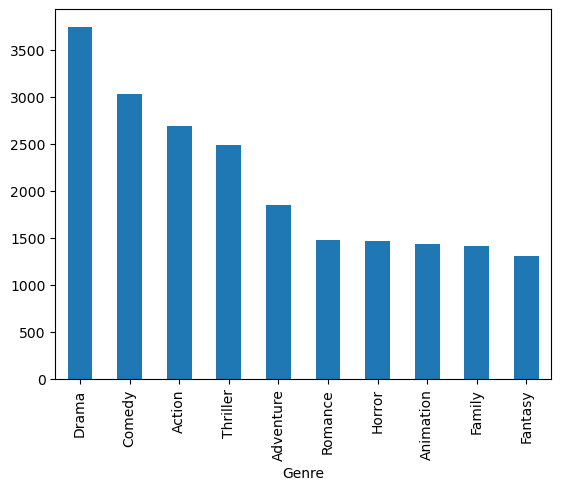

In [274]:
genres.value_counts().head(10).plot.bar()
plt.savefig("/Users/deepali/Movie_Industry_Analysis/images/movies_per_year.png")

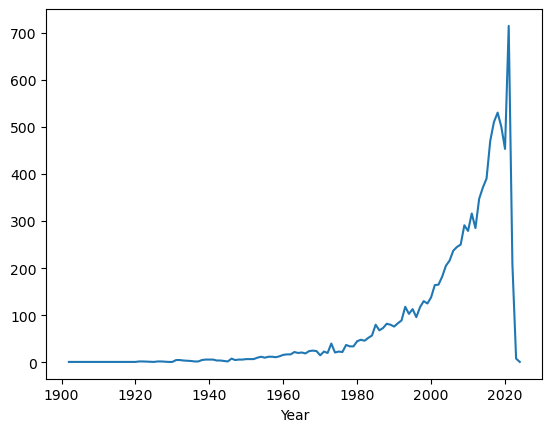

In [272]:
df["Year"].value_counts().sort_index().plot()
plt.savefig("/Users/deepali/Movie_Industry_Analysis/images/year_count.png")

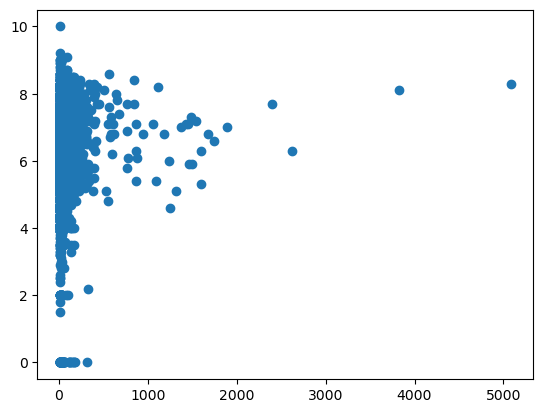

In [276]:
import matplotlib.pyplot as plt
plt.scatter(
    df["Popularity"],
    df["Vote_Average"]
)
plt.savefig("/Users/deepali/Movie_Industry_Analysis/images/Scatter.png")